# Import, Classes, Functions

In [ ]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import scipy.special as sp

#--------------------------------
# setting
#--------------------------------
# plot inside notebook to be pdf format
# from IPython.display import set_matplotlib_formats
# Set matplotlib format to PDF
# set_matplotlib_formats('pdf')
#--------------------------------
# Install LaTeX so that figure title can use latex
#!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
#!pip install pypandoc

# After installation, you might need to configure Matplotlib to use LaTeX
# plt.rcParams['text.usetex'] = True
#--------------------------------



# plt.style.use({'figure.facecolor': 'white'})
# usetex does not work in colab
# plt.matplotlib.rc('text', usetex = True)
plt.matplotlib.rc('grid', linestyle = 'dotted')
#plt.style.use('dark_background')
#%matplotlib inline
# from google.colab import files

rng = np.random.default_rng(12345)


#----------------------------------
# functions, classes
#----------------------------------

#------------------------------
def plot_complex_vector(t_xt, xt, str_xt='x(t)',
                        xt_ylabel='$\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
                        xt_xlabel='time ($t_b$)',
                        fname1='LSM_16QAM_20',
                        IQ_xlabel='$x_I(t)/\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
                        IQ_ylabel='$x_Q(t)/\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
                        ):
    """
    plot magnitude, real, imaginary on top of phase
    plot real vs imag

    plot_complex_vector(t_xt,xt,str_xt='x(t)',
    xt_ylabel='$\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
    xt_xlabel='time ($t_b$)',
    fname1='LSM_16QAM_20',
    IQ_xlabel='$x_I(t)/\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
    IQ_ylabel='$x_Q(t)/\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
    )

    return fig1, fig2
    """
    # t_xt, xt, str_xt
    #fig1 = plt.figure(figsize=(6, 4))
    fig1, axs = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 1]})
    fig1ax1=axs[0]
    fig1ax2=axs[1]
    #--------
    # magnitude, real, imag
    #--------
    #fig1ax1 = fig1.add_axes([0.05, 0.25, 0.95, 0.75])
    #fig1ax1 = fig1.add_subplot(211)
    fig1ax1.plot(t_xt, abs(xt), '-b', label='$|' + str_xt + '|$')
    fig1ax1.plot(t_xt, np.real(xt), ':r', label='$\Re[' + str_xt + ']$')
    fig1ax1.plot(t_xt, np.imag(xt), ':g', label='$\Im[' + str_xt + ']$')
    fig1ax1.grid(which='both', linestyle=':')
    #fig1ax1.set_xlabel('time ($t_b$)')
    fig1ax1.set_ylabel(xt_ylabel)
    #fig1ax1.legend(loc='upper right',facecolor=(1, 1, 1, 0.0001))
    #fig1ax1.legend(loc='lower right')
    fig1ax1.legend(loc='best')
    #--------
    # phase
    #--------
    #fig1ax2 = fig1.add_axes([0.05, 0.05, 0.95, 0.2])
    #fig1ax1 = fig1.add_subplot(212)
    fig1ax2.plot(t_xt, np.angle(xt) / np.pi, '.m', markersize=1, label='$\\angle ' + str_xt + '$')
    fig1ax2.grid(which='both', linestyle=':')
    fig1ax2.set_xlabel(xt_xlabel)
    fig1ax2.set_ylabel("($\pi$)")
    fig1ax2.legend(loc='upper right')
    #fig1ax1.set_title('Data Symbols=' + np.array2string(dk))

    plt.show()
    fig1.savefig(fname1 + '.eps', format='eps')

    #--------------------------
    # I/Q plot
    #--------------------------
    fig2 = plt.figure(figsize=(6, 6))
    #fig1ax1=fig1.add_axes([0,0,1,1])
    fig2ax1 = fig2.add_subplot(111)
    fig2ax1.plot(np.real(xt), np.imag(xt), linewidth=0.5)  # Plot I/Q
    #fig1ax1.grid(which='both', linestyle=':')
    fig2ax1.set_xlabel(IQ_xlabel)
    fig2ax1.set_ylabel(IQ_ylabel)
    #f1.set_title(strgt)

    plt.show()
    #print(tut)
    fig2.savefig(fname1 + '_IQ.eps', format='eps')
    return fig1, fig2

#-------------------------------------------------------------
# I/Q Up Converter
#-------------------------------------------------------------
class IQUp:

    def __init__(self,fcxsample_period_passband,n_fc2b):

        self.output=0
        self.root2=np.sqrt(2)
        # This is the fc * sample period at passband
        self.fcxsample_period_passband=fcxsample_period_passband
        self.n_fc2b=n_fc2b

    def update(self,input,t0=0):
        # t0, the unit is (symbol period/n_samples_per_symbol)
        idx_input=np.arange(input.size)*self.n_fc2b
        idx_output=np.arange(input.size*self.n_fc2b)
        time_shifted=idx_output+t0*self.n_fc2b
        r2cos=self.root2*np.cos(2*np.pi*self.fcxsample_period_passband*time_shifted)
        r2sin=self.root2*np.sin(2*np.pi*self.fcxsample_period_passband*time_shifted)
        # linearly interpolate the baseband signal to passband sampling rate before I/Q up
        # use np.repeat for 0-th order hold, if wanted, which needs very high sampling rate
        self.output=np.interp(idx_output,idx_input,input.real)*r2cos\
                     -np.interp(idx_output,idx_input,input.imag)*r2sin

#-------------------------------------------------------------
# I/Q Down Converter
#-------------------------------------------------------------
class IQDown:

    def __init__(self,fcxsample_period_passband,n_fc2b,low_pass_h):
        self.low_pass_h=low_pass_h
        self.fcxsample_period_passband=fcxsample_period_passband
        self.n_fc2b=n_fc2b

        self.output=0
        self.root2=np.sqrt(2)
        self.low_pass_tail_len=np.floor(low_pass_h.size/2).astype(int)

    def update(self,input,t0=0):
        # t0, the unit is (symbol period/n_samples_per_symbol)
        time_shifted=np.arange(input.size)+t0*self.n_fc2b
        # down sample by n_fc2b and also make the start time to be t0
        # The time needs to be carefully calculated
        # The convolution is the impulse reponse flipped and shifted to the time
        # If it is the sinc, then we need to shift the center to t0 to produce
        # the output at t0
        idx_output=np.arange(np.floor(input.size/self.n_fc2b).astype(int))*self.n_fc2b\
                  +self.low_pass_tail_len
        #print(idx_output)

        self.output=np.convolve(
            input*self.root2*np.exp(-1j*2*np.pi*self.fcxsample_period_passband*time_shifted),
            self.low_pass_h)[idx_output]

#-------------------------------------------------------------
def linearStreamModulator(ut, dk, numSamplePerSymbol):
    """
    Linear stream modulator
    """
    idx = np.arange(len(ut))
    xt = np.zeros(len(ut) + (len(dk) - 1) * numSamplePerSymbol,dtype=complex)
    for i_symbol in range(len(dk)):
        xt[idx + i_symbol * numSamplePerSymbol] += ut * dk[i_symbol]

    return xt
#-------------------------------------------------------------
help(linearStreamModulator)
#-------------------------------------------------------------



<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\l'
<>:72: SyntaxWarning: invalid escape sequence '\R'
<>:73: SyntaxWarning: invalid escape sequence '\I'
<>:88: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\l'
<>:44: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\l'
<>:72: SyntaxWarning: invalid escape sequence '\R'
<>:73: SyntaxWarning: invalid escape sequence '\I'
<>:88: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_98972/3265272234.py:41: SyntaxWarning: invalid escape sequence '\l'
  xt_ylabel='$\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
/tmp/ipykernel_98972/3265272234.py:44: SyntaxWarning: invalid escape sequence '\l'
  IQ_xlabel='$x_I(t)/\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
/

Help on function linearStreamModulator in module __main__:

linearStreamModulator(ut, dk, numSamplePerSymbol)
    Linear stream modulator



# I/Q Up and Down Converters

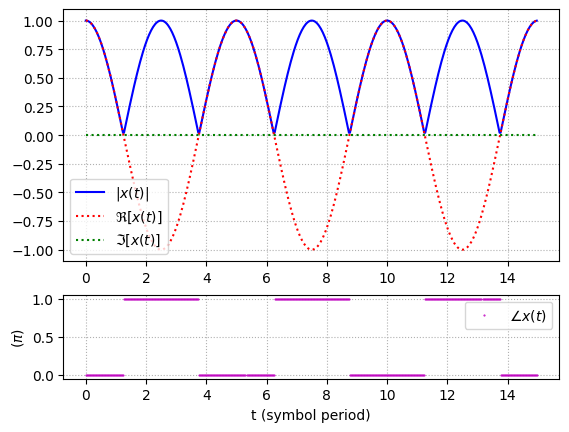

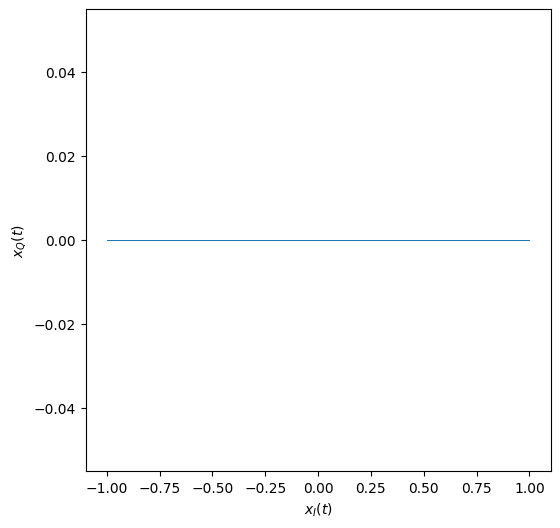

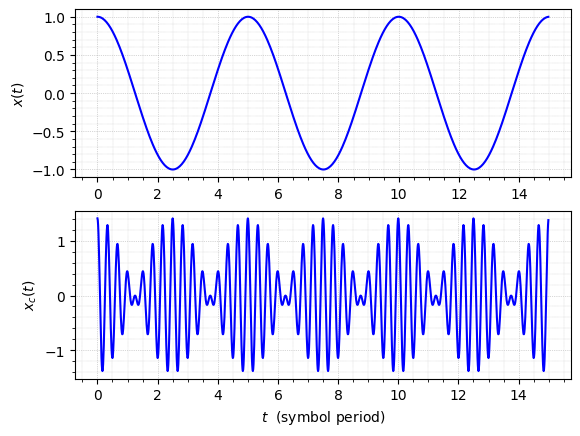

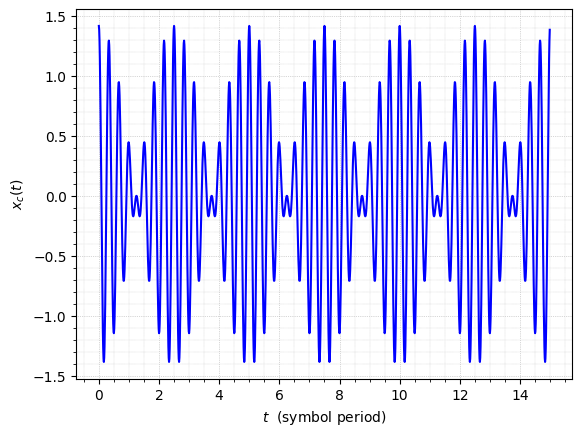

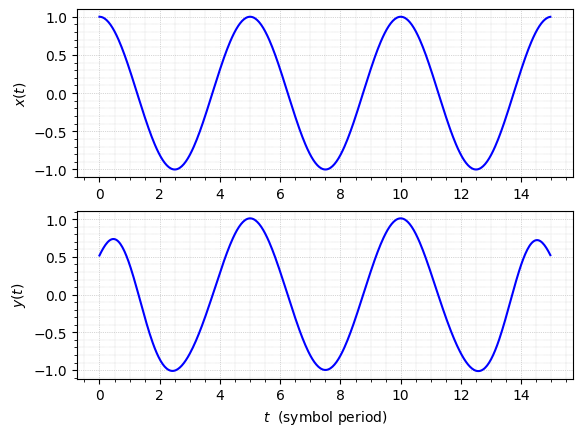

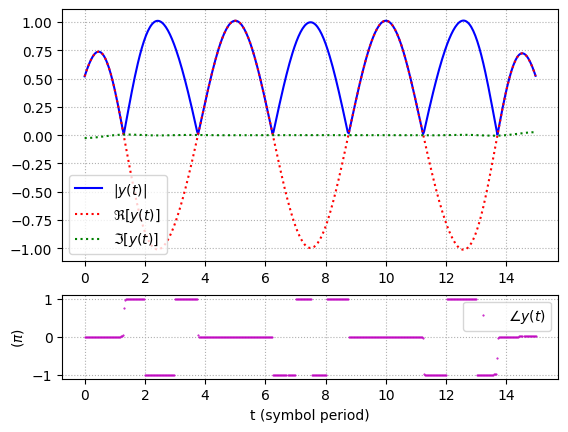

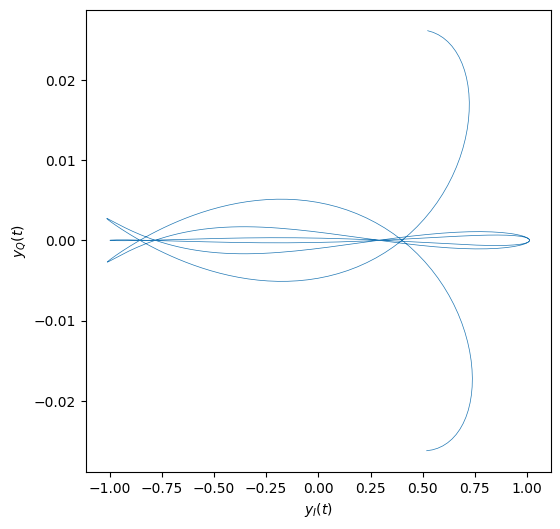

(<Figure size 640x480 with 2 Axes>, <Figure size 600x600 with 1 Axes>)

In [12]:

# test class IQUp

# plot
n_samples_per_symbol=30
b=5.*10**6
fc=15.*10**6
n_fc2b=round(fc/b)
fcxsample_period_passband=fc/b/n_fc2b/n_samples_per_symbol

t0=0*n_samples_per_symbol #the unit is (symbol period/n_samples_per_symbol)
# create baseband signals
tt=(np.arange(15*n_samples_per_symbol)+t0)/n_samples_per_symbol
f_b=0.2 # the frequency unit is b
xt=1*np.cos(2*np.pi*f_b*tt)
#xt=np.exp(1j*2*np.pi*f_b*tt)

iqup_1=IQUp(fcxsample_period_passband,n_fc2b)
iqup_1.update(xt,t0)
xct=iqup_1.output

tt_c=np.arange(xct.size)/(n_samples_per_symbol*n_fc2b)+t0/n_samples_per_symbol
plot_complex_vector(tt, xt, str_xt='x(t)',
                        xt_ylabel='',
                        xt_xlabel='t (symbol period)',
                        fname1='ex_IQup_fig3',
                        IQ_xlabel='$x_I(t)$',
                        IQ_ylabel='$x_Q(t)$',
                        )

#--------------------------------------------------
fig1, fig1ax = plt.subplots(2, 1)
#fig1ax1.plot(tt_c,xct, '-b')
fig1ax1=fig1ax[0]
fig1ax1.plot(tt,xt, '-b')
#fig1ax1.grid(which='both', linestyle=':')
fig1ax1.grid(which='major', linestyle=':', linewidth=0.5)
fig1ax1.grid(which='minor', linestyle=':', linewidth=0.3)
fig1ax1.minorticks_on()
#fig1ax1.set_xlabel('$t$  (symbol period)')
fig1ax1.set_ylabel('$x(t)$')
#fig1ax1.legend(loc='upper right',facecolor=(1, 1, 1, 0.0001))
#fig1ax1.legend(loc='lower right')
#fig1ax1.legend(loc='best')
#fig1ax1.set_title('Data Symbols=' + np.array2string(dk))

#plt.show()
#fig1.savefig('rhf.eps', format='eps')
#--------------------------------------------------
#fig1, fig1ax1 = plt.subplots(1, 1)
fig1ax1=fig1ax[1]
fig1ax1.plot(tt_c,xct, '-b')
#fig1ax1.plot(tt,xt, '-b')
#fig1ax1.grid(which='both', linestyle=':')
fig1ax1.grid(which='major', linestyle=':', linewidth=0.5)
fig1ax1.grid(which='minor', linestyle=':', linewidth=0.3)
fig1ax1.minorticks_on()
fig1ax1.set_xlabel('$t$  (symbol period)')
fig1ax1.set_ylabel('$x_c(t)$')
#fig1ax1.legend(loc='upper right',facecolor=(1, 1, 1, 0.0001))
#fig1ax1.legend(loc='lower right')
#fig1ax1.legend(loc='best')
#fig1ax1.set_title('Data Symbols=' + np.array2string(dk))

plt.show()
fig1.savefig('ex_IQup_fig1.eps', format='eps')

#--------------------------------------------------
# only plot x_c(t)
fig1, fig1ax1 = plt.subplots(1, 1)
fig1ax1.plot(tt_c,xct, '-b')
#fig1ax1.plot(tt,xt, '-b')
#fig1ax1.grid(which='both', linestyle=':')
fig1ax1.grid(which='major', linestyle=':', linewidth=0.5)
fig1ax1.grid(which='minor', linestyle=':', linewidth=0.3)
fig1ax1.minorticks_on()
fig1ax1.set_xlabel('$t$  (symbol period)')
fig1ax1.set_ylabel('$x_c(t)$')
#fig1ax1.legend(loc='upper right',facecolor=(1, 1, 1, 0.0001))
#fig1ax1.legend(loc='lower right')
#fig1ax1.legend(loc='best')
#fig1ax1.set_title('Data Symbols=' + np.array2string(dk))

plt.show()
fig1.savefig('ex_IQup_fig4.eps', format='eps')

# Test I/Q down converter

# generate sampled low pass filter impulse response * sample interval for passbandsampling rate
# the bandwidth is assumed to be the symbol rate. We should use wider band in general
half_width=15*n_samples_per_symbol*n_fc2b
#----------------------------------------------------------------------------------------------
# You need to be careful on the convolution vector generating:
#   The impulse response of an ideal low pass filter is
#   bandwidth*sinc(t*bandwidth)
#   To use discrete time convolution, we need to multiply the sample period to the impulse response, as
#   bandwidth*sinc(t*bandwidth)*sample_period
#   If t=t' (1/bandwidth) and sample_period= s' (1/bandwidth)
# Then the convolution vector low_pass_h = s'sinc(t')
#----------------------------------------------------------------------------------------------
low_pass_h=np.sinc(np.arange(-half_width,half_width+1)/(n_samples_per_symbol*n_fc2b))\
    /(n_samples_per_symbol*n_fc2b)

iqdown_1=IQDown(fcxsample_period_passband,n_fc2b,low_pass_h)
iqdown_1.update(iqup_1.output)
yt=iqdown_1.output
tt_y=(np.arange(yt.size)+t0)/n_samples_per_symbol

#--------------------------------------------------
fig1, fig1ax = plt.subplots(2, 1)
#fig1ax1.plot(tt_c,xct, '-b')
fig1ax1=fig1ax[0]
fig1ax1.plot(tt,xt, '-b')
#fig1ax1.grid(which='both', linestyle=':')
fig1ax1.grid(which='major', linestyle=':', linewidth=0.5)
fig1ax1.grid(which='minor', linestyle=':', linewidth=0.3)
fig1ax1.minorticks_on()
#fig1ax1.set_xlabel('$t$  (symbol period)')
fig1ax1.set_ylabel('$x(t)$')
#fig1ax1.legend(loc='upper right',facecolor=(1, 1, 1, 0.0001))
#fig1ax1.legend(loc='lower right')
#fig1ax1.legend(loc='best')
#fig1ax1.set_title('Data Symbols=' + np.array2string(dk))

#plt.show()
#fig1.savefig('rhf.eps', format='eps')
#--------------------------------------------------
#fig1, fig1ax1 = plt.subplots(1, 1)
fig1ax1=fig1ax[1]
fig1ax1.plot(tt_y,yt.real, '-b')
#fig1ax1.plot(tt,xt, '-b')
#fig1ax1.grid(which='both', linestyle=':')
fig1ax1.grid(which='major', linestyle=':', linewidth=0.5)
fig1ax1.grid(which='minor', linestyle=':', linewidth=0.3)
fig1ax1.minorticks_on()
fig1ax1.set_xlabel('$t$  (symbol period)')
fig1ax1.set_ylabel('$y(t)$')
#fig1ax1.legend(loc='upper right',facecolor=(1, 1, 1, 0.0001))
#fig1ax1.legend(loc='lower right')
#fig1ax1.legend(loc='best')
#fig1ax1.set_title('Data Symbols=' + np.array2string(dk))

plt.show()
#fig1.savefig('ex_IQup_fig1.eps', format='eps')

plot_complex_vector(tt_y,yt, str_xt='y(t)',
                        xt_ylabel='',
                        xt_xlabel='t (symbol period)',
                        fname1='ex_IQDown_fig1',
                        IQ_xlabel='$y_I(t)$',
                        IQ_ylabel='$y_Q(t)$',
                        )



# Wireless Channels

## General case, exercise

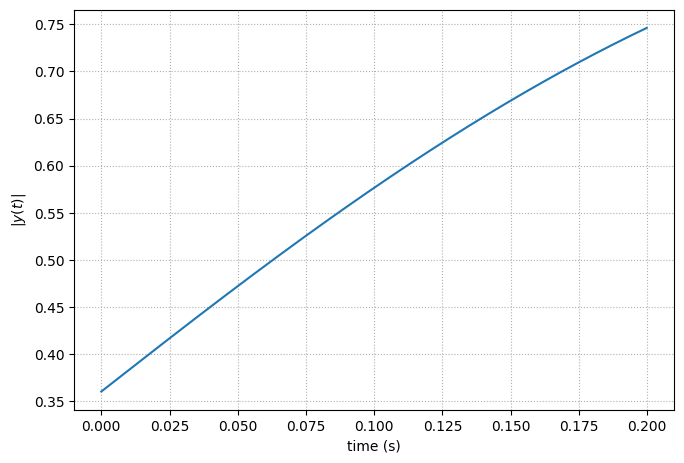

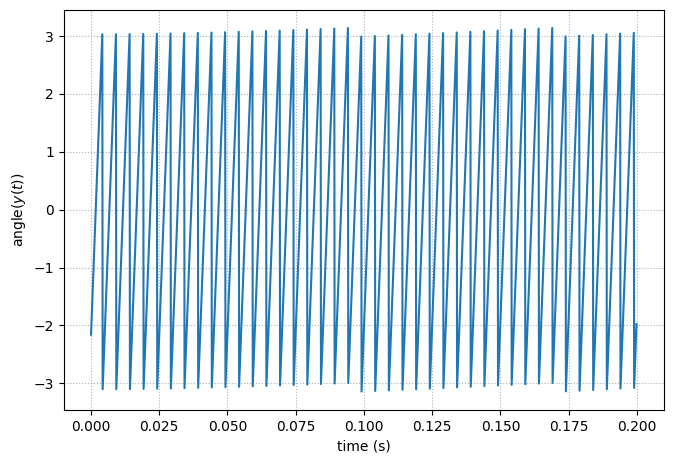

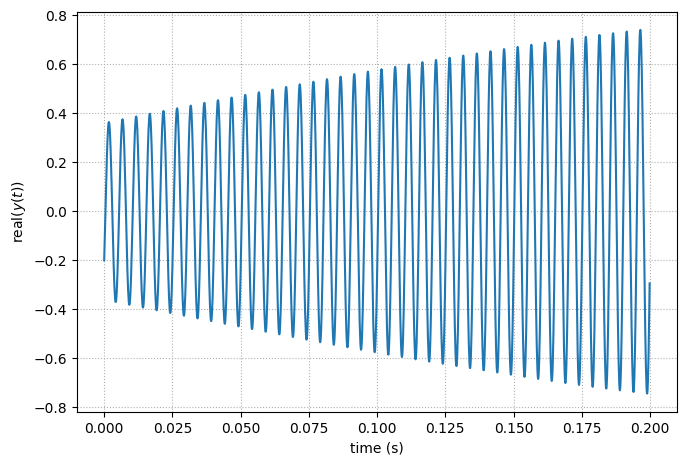

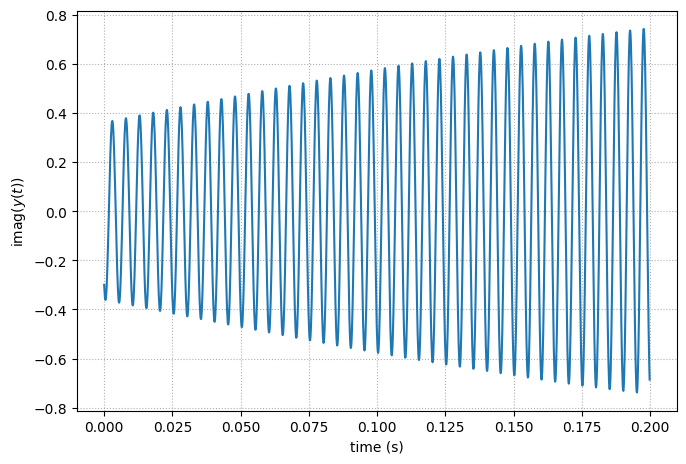

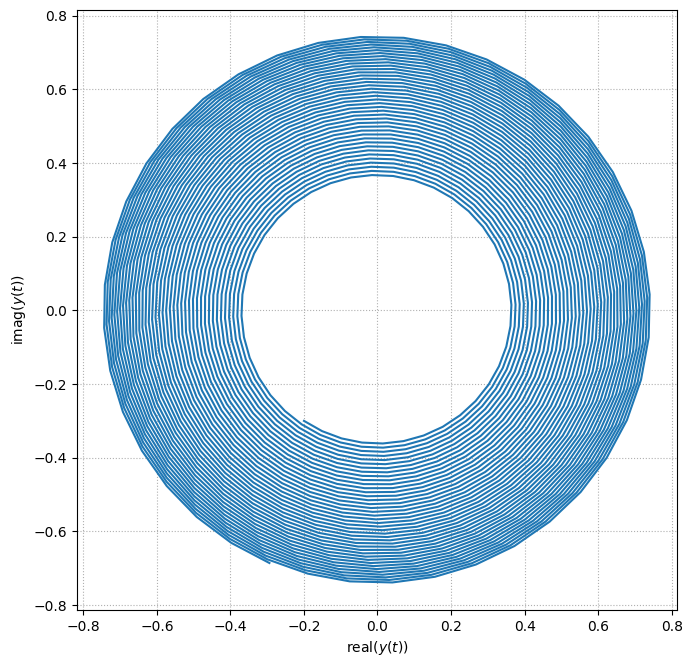

In [13]:
#endt=0.2
#tt=np.linspace(0,endt,endt/800)
tt = np.arange(0, 0.2, 1 / 8000.)
y = (0.1 - 0.5 * 1j) * np.exp(1j * 2 * np.pi * 200 * tt) + (-0.3 + 0.2 * 1j) * np.exp(1j * 2 * np.pi * (201) * tt)

#-------------------------------------------
fig1 = plt.figure(figsize=(6, 4))
fig1ax1 = fig1.add_axes([0, 0, 1, 1])
fig1ax1.plot(tt, np.abs(y))  # Plot magnitude
fig1ax1.grid(which='both', linestyle=':')
fig1ax1.set_xlabel('time (s)')
fig1ax1.set_ylabel('$|y(t)|$')
#-------------------------------------------
fig1 = plt.figure(figsize=(6, 4))
fig1ax1 = fig1.add_axes([0, 0, 1, 1])
fig1ax1.plot(tt, np.angle(y))  # Plot angle
fig1ax1.grid(which='both', linestyle=':')
fig1ax1.set_xlabel('time (s)')
fig1ax1.set_ylabel('angle$(y(t))$')
#-------------------------------------------
fig1 = plt.figure(figsize=(6, 4))
fig1ax1 = fig1.add_axes([0, 0, 1, 1])
fig1ax1.plot(tt, np.real(y))  # Plot real part
fig1ax1.grid(which='both', linestyle=':')
fig1ax1.set_xlabel('time (s)')
fig1ax1.set_ylabel('real$(y(t))$')
#-------------------------------------------
fig1 = plt.figure(figsize=(6, 4))
fig1ax1 = fig1.add_axes([0, 0, 1, 1])
fig1ax1.plot(tt, np.imag(y))  # Plot imaginary part
fig1ax1.grid(which='both', linestyle=':')
fig1ax1.set_xlabel('time (s)')
fig1ax1.set_ylabel('imag$(y(t))$')
#-------------------------------------------
fig1 = plt.figure(figsize=(6, 6))
fig1ax1 = fig1.add_axes([0, 0, 1, 1])
fig1ax1.plot(np.real(y), np.imag(y))  # Plot I/Q
fig1ax1.grid(which='both', linestyle=':')
fig1ax1.set_xlabel('real$(y(t))$')
fig1ax1.set_ylabel('imag$(y(t))$')
#f1.set_title(strgt)

plt.show()

#fig1.savefig('fading_2path_IQ.eps', format='eps')
#files.download('fading_2path_IQ.eps')

#! ls

2 paths

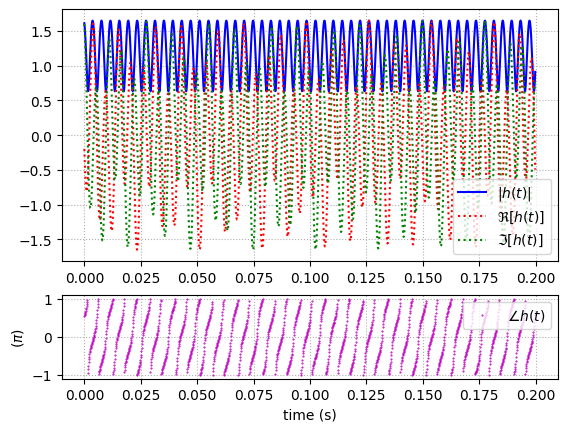

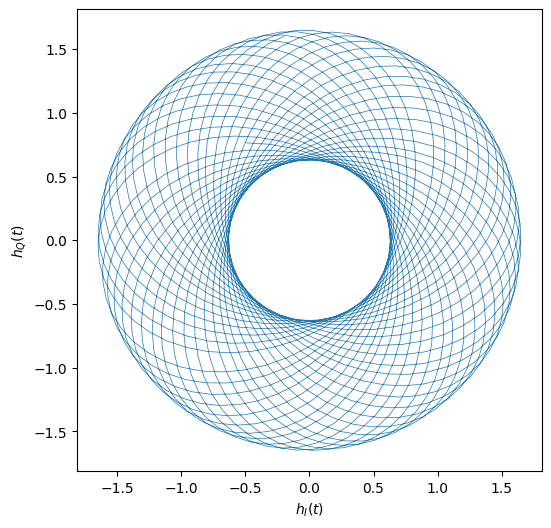

In [14]:
#endt=0.2
#tt=np.linspace(0,endt,endt/800)
tt = np.arange(0, 0.2, 1 / 8000.)

a_vec=np.array([(0.1 + 0.5 * 1j),(-0.3 + 1.1 * 1j)])
f_vec=np.array([-73, 180])
ht=np.zeros(len(tt),dtype=complex)
for i_path in range(len(a_vec)):
    ht+= a_vec[i_path] * np.exp(1j * 2 * np.pi * f_vec[i_path] * tt)

fig1, fig2=plot_complex_vector(tt,ht,str_xt='h(t)',
    xt_ylabel='',
    xt_xlabel='time (s)',
    fname1='fading_flat2path',
    IQ_xlabel='$h_I(t)$',
    IQ_ylabel='$h_Q(t)$',
    )

3 paths

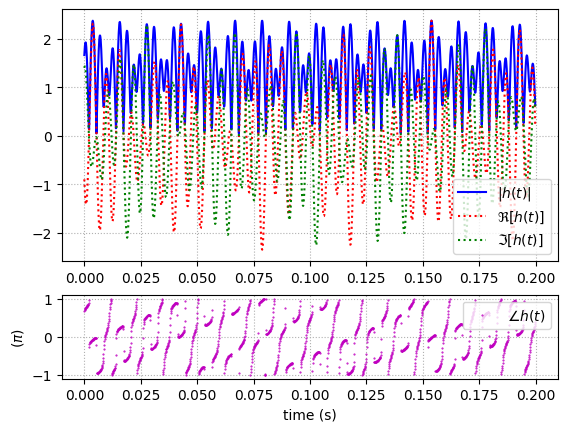

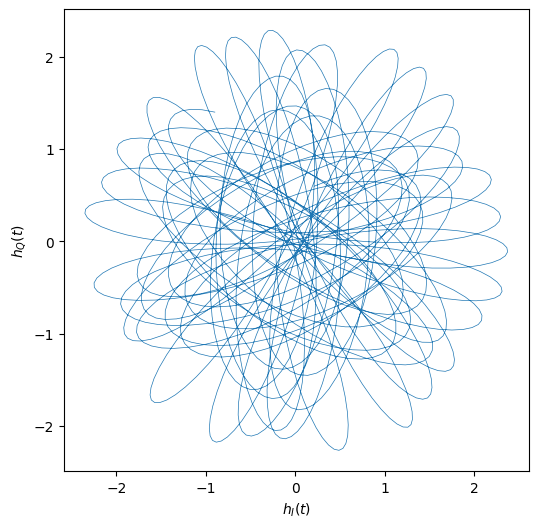

In [15]:
#endt=0.2
#tt=np.linspace(0,endt,endt/800)
tt = np.arange(0, 0.2, 1 / 8000.)

a_vec=np.array([(0.1 + 0.5 * 1j),(-0.3 + 1.1 * 1j),(-0.7 - 0.2 * 1j)])
f_vec=np.array([-73, 180, -153])
ht=np.zeros(len(tt),dtype=complex)
for i_path in range(len(a_vec)):
    ht+= a_vec[i_path] * np.exp(1j * 2 * np.pi * f_vec[i_path] * tt)

fig1, fig2=plot_complex_vector(tt,ht,str_xt='h(t)',
    xt_ylabel='',
    xt_xlabel='time (s)',
    fname1='fading_flat3path',
    IQ_xlabel='$h_I(t)$',
    IQ_ylabel='$h_Q(t)$',
    )

## Special Case: Slowly Time Varying Flat Fading

plot r_h(tau)

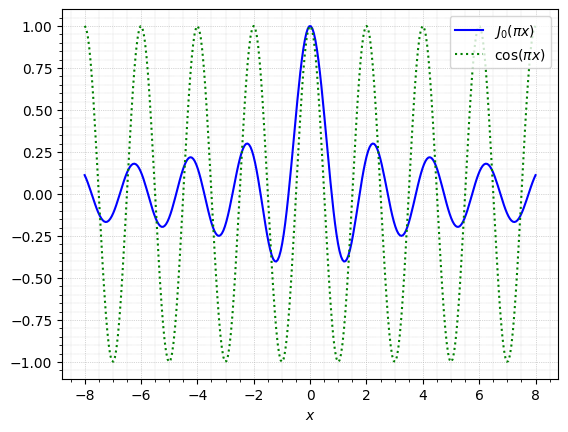

In [16]:
tt=np.linspace(-8,8,300)
rht=sp.j0(np.pi*tt)
#--------------------------------------------------
fig1, fig1ax1 = plt.subplots(1, 1)
fig1ax1.plot(tt, rht, '-b',label='$J_{0}(\\pi x)$')
fig1ax1.plot(tt, np.cos(tt*np.pi), ':g',label='$\\cos(\\pi x)$')
#fig1ax1.grid(which='both', linestyle=':')
fig1ax1.grid(which='major', linestyle=':', linewidth=0.5)
fig1ax1.grid(which='minor', linestyle=':', linewidth=0.3)
fig1ax1.minorticks_on()
fig1ax1.set_xlabel('$x$')
#fig1ax1.set_ylabel('$J_{0}(\\pi x)$')
#fig1ax1.legend(loc='upper right',facecolor=(1, 1, 1, 0.0001))
#fig1ax1.legend(loc='lower right')
fig1ax1.legend(loc='best')
#fig1ax1.set_title('Data Symbols=' + np.array2string(dk))

plt.show()
fig1.savefig('J0.eps', format='eps')

plot \tilde{r}_h(f)

<ipython-input-17-9d81060a4c81>:2: RuntimeWarning: divide by zero encountered in divide
  rhf=1/np.pi/np.sqrt(1-(ff**2))


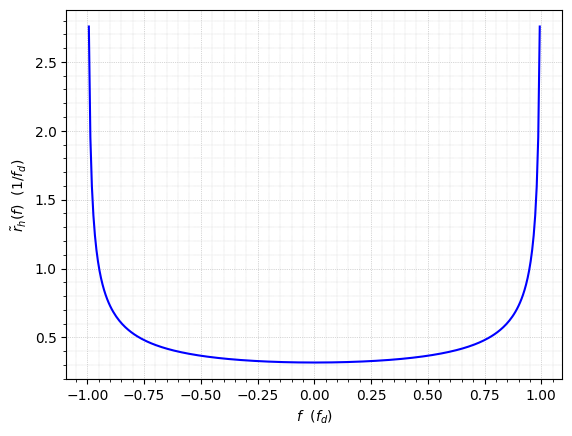

In [17]:
ff=np.linspace(-1,1,300)
rhf=1/np.pi/np.sqrt(1-(ff**2))
#--------------------------------------------------
fig1, fig1ax1 = plt.subplots(1, 1)
fig1ax1.plot(ff, rhf, '-b')
#fig1ax1.grid(which='both', linestyle=':')
fig1ax1.grid(which='major', linestyle=':', linewidth=0.5)
fig1ax1.grid(which='minor', linestyle=':', linewidth=0.3)
fig1ax1.minorticks_on()
fig1ax1.set_xlabel('$f$  $(f_d)$')
fig1ax1.set_ylabel('$\\tilde{r}_{h}(f)$  $(1/f_d)$')
#fig1ax1.legend(loc='upper right',facecolor=(1, 1, 1, 0.0001))
#fig1ax1.legend(loc='lower right')
#fig1ax1.legend(loc='best')
#fig1ax1.set_title('Data Symbols=' + np.array2string(dk))

plt.show()
fig1.savefig('rhf.eps', format='eps')
#--------------------------------------------------

# Modulator

## Linear Stream Modulation and Linear Modulation

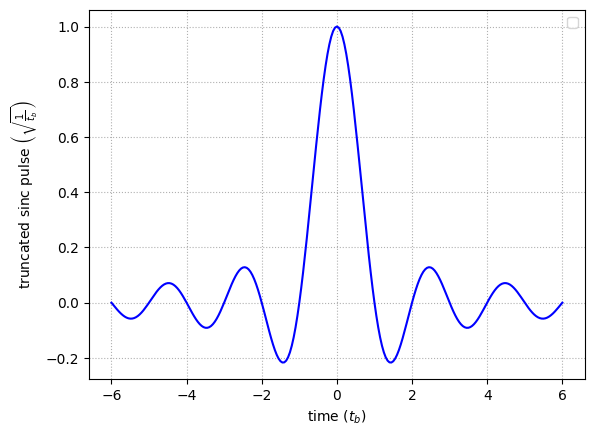

[ 1 -1  1 -1 -1  1  1  1  1 -1]


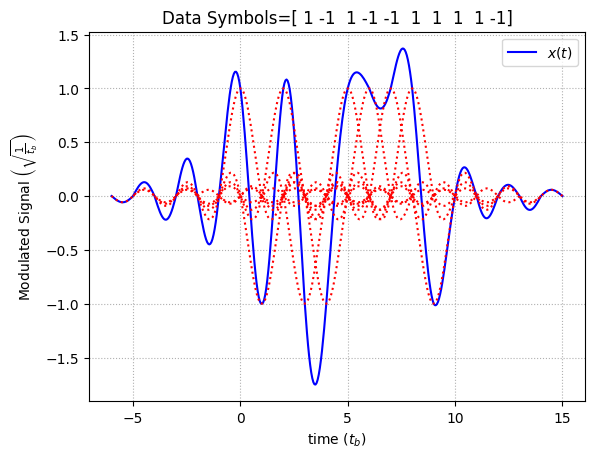

In [18]:

#---------------------------------------------------------------
# sinc pulse
#---------------------------------------------------------------
#ut=np.array([1.,1.,1.])

#fb = 5 * 10 ** 6  # symbol rate
numSamplePerSymbol = 20
#fs = fb * numSamplePerSymbol

tut = np.arange(-6 * numSamplePerSymbol, 6 * numSamplePerSymbol + 1) / numSamplePerSymbol
ut = np.sinc(tut)

#-------------------------------------------
#fig1 = plt.figure(figsize=(6, 4))
fig1 = plt.figure()
fig1ax1 = fig1.add_subplot(111)

fig1ax1.plot(tut, ut, '-b')

fig1ax1.set_xlabel('time ($t_b$)')
fig1ax1.set_ylabel('truncated sinc pulse $\left ( \sqrt{\\frac{1}{t_b}} \\right)$')
#fig1ax1.set_title('Data Symbols=' + np.array2string(dk))

fig1ax1.grid(which='both', linestyle=':')
plt.legend()
plt.show()

fig1.savefig('sinc_pulse.eps', format='eps')

#---------------------------------------------------------------
# modulated
#---------------------------------------------------------------
#ut=np.array([1.,1.,1.])

#fb = 5 * 10 ** 6  # symbol rate
numSamplePerSymbol = 20
#fs = fb * numSamplePerSymbol

tut = np.arange(-6 * numSamplePerSymbol, 6 * numSamplePerSymbol + 1) / numSamplePerSymbol
ut = np.sinc(tut)

dk = rng.integers(low=0, high=2, size=10) * 2 - 1
print(dk)
#dk=np.array([1])

xt = linearStreamModulator(ut, dk, numSamplePerSymbol)
t_xt = (np.arange(0, len(xt)) - 6 * numSamplePerSymbol) / numSamplePerSymbol
#-------------------------------------------
#fig1 = plt.figure(figsize=(6, 4))
fig1 = plt.figure()
fig1ax1 = fig1.add_subplot(111)
fig1ax1.plot(t_xt, xt, '-b', label='$x(t)$')
for i_symbol in range(len(dk)):
    fig1ax1.plot(tut + i_symbol,
                 ut * dk[i_symbol], ':r', )

fig1ax1.grid(which='both', linestyle=':')
fig1ax1.set_xlabel('time ($t_b$)')
fig1ax1.set_ylabel('Modulated Signal $\left ( \sqrt{\\frac{1}{t_b}} \\right)$')
fig1ax1.set_title('Data Symbols=' + np.array2string(dk))
plt.legend()
plt.show()

fig1.savefig('LSM_BPSK.eps', format='eps')

### constellation

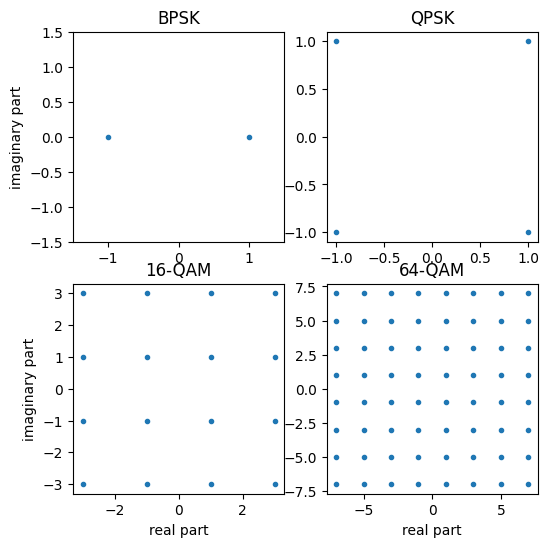

In [19]:
cstl_BPSK=np.array([-1,1])
cstl_QPSK=np.array([-1-1j, -1+1j,1-1j, 1+1j])
cstl_16QAM=np.array([-3-3j, -3-1j, -1-3j, -1-1j,
                     -3+3j, -3+1j, -1+3j, -1+1j,
                     3-3j, 3-1j, 1-3j, 1-1j,
                     3+3j, 3+1j, 1+3j, 1+1j])
cstl_64QAM=np.append(cstl_16QAM+4*(-1-1j),cstl_16QAM+4*(-1+1j))
cstl_64QAM=np.append(cstl_64QAM,cstl_16QAM+4*(1-1j))
cstl_64QAM=np.append(cstl_64QAM,cstl_16QAM+4*(1+1j))
#-------------------------------------------
fig1 = plt.figure(figsize=(6, 6))
#fig1ax1=fig1.add_axes([0,0,1,1])
#------------------
fig1ax1 = fig1.add_subplot(221)
fig1ax1.plot(np.real(cstl_BPSK), np.imag(cstl_BPSK),'.', linestyle='')  # Plot I/Q
#fig1ax1.grid(which='both', linestyle=':')
#fig1ax1.set_xlabel('real part')
fig1ax1.set_ylabel('imaginary part')
fig1ax1.set_title('BPSK')
fig1ax1.set_xlim([-1.5, 1.5])
fig1ax1.set_ylim([-1.5, 1.5])
#------------------
fig1ax1 = fig1.add_subplot(222)
fig1ax1.plot(np.real(cstl_QPSK), np.imag(cstl_QPSK),'.', linestyle='')  # Plot I/Q
#fig1ax1.grid(which='both', linestyle=':')
#fig1ax1.set_xlabel('real part')
#fig1ax1.set_ylabel('imaginary part')
fig1ax1.set_title('QPSK')

#------------------
fig1ax1 = fig1.add_subplot(223)
fig1ax1.plot(np.real(cstl_16QAM), np.imag(cstl_16QAM),'.', linestyle='')  # Plot I/Q
#fig1ax1.grid(which='both', linestyle=':')
fig1ax1.set_xlabel('real part')
fig1ax1.set_ylabel('imaginary part')
fig1ax1.set_title('16-QAM')
#------------------
fig1ax1 = fig1.add_subplot(224)
fig1ax1.plot(np.real(cstl_64QAM), np.imag(cstl_64QAM),'.', linestyle='')  # Plot I/Q
#fig1ax1.grid(which='both', linestyle=':')
fig1ax1.set_xlabel('real part')
#fig1ax1.set_ylabel('imaginary part')
fig1ax1.set_title('64-QAM')
#plt.legend()
plt.show()
fig1.savefig('constellation.eps', format='eps')

### 16-QAM modulation example

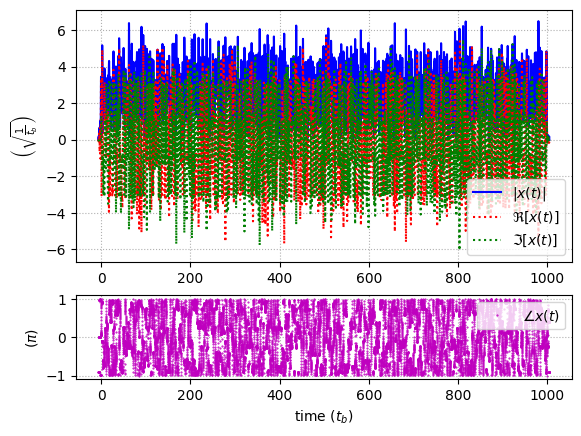

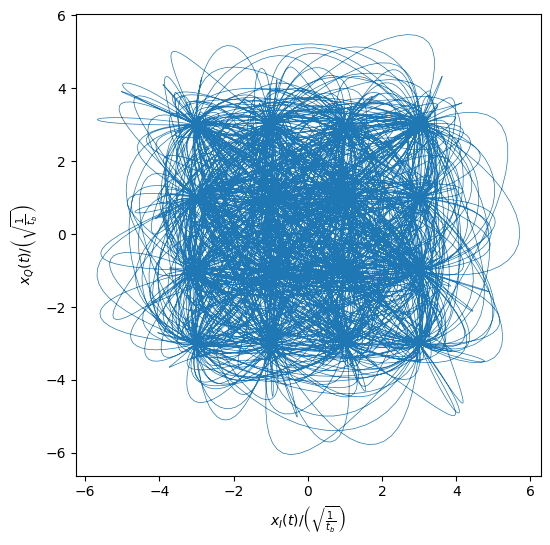

In [20]:
numSamplePerSymbol = 20
tut = np.arange(-6 * numSamplePerSymbol, 6 * numSamplePerSymbol + 1) / numSamplePerSymbol
ut = np.sinc(tut)
#print(ut*(1-1j))
dk = cstl_16QAM[rng.integers(low=0, high=16, size=1000)]
#print(dk)

xt = linearStreamModulator(ut, dk, numSamplePerSymbol)
t_xt = (np.arange(0, len(xt)) - 6 * numSamplePerSymbol) / numSamplePerSymbol

fig1, fig2=plot_complex_vector(t_xt,xt,str_xt='x(t)',
    xt_ylabel='$\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
    xt_xlabel='time ($t_b$)',
    fname1='LSM_16QAM_1000',
    IQ_xlabel='$x_I(t)/\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
    IQ_ylabel='$x_Q(t)/\left ( \sqrt{\\frac{1}{t_b}} \\right)$',
    )